<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Dermatology/incremental_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Dermatology/'

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Mounted at /content/drive
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "class"]

X_train, y_train = train_df[feature_cols], train_df["class"]
X_val, y_val = val_df[feature_cols], val_df["class"]
X_test, y_test = test_df[feature_cols], test_df["class"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

minority_to_majority_order = [6, 4, 5, 2, 3, 1]  # pityriasis_rubra_pilaris, pityriasis_rosea, chronic_dermatitis, seboreic_dermatitis, lichen_planus, psoriasis
CLASS_NAMES = {1: "psoriasis", 2: "seboreic_dermatitis", 3: "lichen_planus",
               4: "pityriasis_rosea", 5: "chronic_dermatitis", 6: "pityriasis_rubra_pilaris"}
label_to_index = {label: i for i, label in enumerate(minority_to_majority_order)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 233  Val: 59  Test: 74
{6: 0, 4: 1, 5: 2, 2: 3, 3: 4, 1: 5}


# Convert to tensors

In [ ]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([233, 34]) torch.Size([233])


# Defining a growable network with a permanent skip connection

In [ ]:
class GrowableNet(nn.Module):
    """
    A network that can grow one hidden neuron or one output class at a
    time, keeping all previously learned weights.

    Structure: a permanent direct input->output ("skip") connection,
    plus an optional growing hidden pathway layered on top. The skip
    connection is what makes growing from 0 to 1 hidden neuron safe -
    a new hidden neuron's contribution to the output starts at exactly
    zero, so the network computes the same thing right after growing
    as it did right before. Training then decides whether the new
    pathway is worth using.
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.fc_skip = nn.Linear(input_dim, output_dim)  # always present, never discarded

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_hidden_out = None
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_hidden_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fc_skip(x)
        if self.hidden_dim > 0:
            h = torch.tanh(self.fc_hidden(x))
            out = out + self.fc_hidden_out(h)
        return out

    def add_hidden_neuron(self):
        """Grow the hidden pathway by one neuron. fc_skip is untouched.
        Existing hidden neurons keep their weights; the new neuron's
        output contribution is initialised at zero, so growing starts
        as a no-op."""
        if self.hidden_dim == 0:
            new_fc_hidden = nn.Linear(self.input_dim, 1)
            new_fc_hidden_out = nn.Linear(1, self.output_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight.zero_()
                new_fc_hidden_out.bias.zero_()
            self.fc_hidden = new_fc_hidden
            self.fc_hidden_out = new_fc_hidden_out
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_hidden_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_hidden_out.weight[:, :old_dim] = self.fc_hidden_out.weight
            new_fc_hidden_out.weight[:, old_dim:] = 0.0  # new neuron starts silent
            new_fc_hidden_out.bias[:] = self.fc_hidden_out.bias
        self.fc_hidden_out = new_fc_hidden_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class, on both pathways. All
        existing weights are kept; only the new class's weights are
        freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1

        new_fc_skip = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_skip.weight[:old_dim] = self.fc_skip.weight
            new_fc_skip.bias[:old_dim] = self.fc_skip.bias
        self.fc_skip = new_fc_skip

        if self.hidden_dim > 0:
            new_fc_hidden_out = nn.Linear(self.hidden_dim, new_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight[:old_dim] = self.fc_hidden_out.weight
                new_fc_hidden_out.bias[:old_dim] = self.fc_hidden_out.bias
            self.fc_hidden_out = new_fc_hidden_out

        self.output_dim = new_dim


# quick sanity check - start with 2 classes (the two rarest), 0 hidden neurons,
# then grow a hidden neuron and a third output class, same as stage 1 -> stage 2
test_net = GrowableNet(input_dim=34, output_dim=2, hidden_dim=0)
print(test_net)
test_net.add_hidden_neuron()
print(test_net)
test_net.add_output_class()
print(test_net)

GrowableNet(
  (fc_skip): Linear(in_features=34, out_features=2, bias=True)
)
GrowableNet(
  (fc_skip): Linear(in_features=34, out_features=2, bias=True)
  (fc_hidden): Linear(in_features=34, out_features=1, bias=True)
  (fc_hidden_out): Linear(in_features=1, out_features=2, bias=True)
)
GrowableNet(
  (fc_skip): Linear(in_features=34, out_features=3, bias=True)
  (fc_hidden): Linear(in_features=34, out_features=1, bias=True)
  (fc_hidden_out): Linear(in_features=1, out_features=3, bias=True)
)


# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active at a given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Live diagnosis function

In [ ]:
def diagnose_incremental(curr_val_loss, curr_no_skill, history, best_epoch,
                          prev_val_loss=None, prev_stage_final_ratio=None,
                          min_improvement=0.02, ratio_margin=0.05,
                          diverge_delta=0.01, underfit_ratio=0.8):
    """
    Live, backward-only diagnosis - never looks at architectures that
    haven't been trained yet. Three cases, in order of preference:

    1. Not the first architecture tried in this stage (prev_val_loss given):
       did adding the last neuron meaningfully reduce val loss, on the
       *same* class set? Direct, reliable comparison.
    2. First architecture in a stage after stage 1 (prev_stage_final_ratio
       given): compare this stage's starting ratio (val loss / no-skill,
       for this stage's classes) against how good the ratio was right
       before this class was added.
    3. Truly the first thing ever tried, stage 1, nothing to compare
       against at all - the only case using the absolute no-skill check.
    """
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    is_overfitting_trend = (final_val > val_loss + diverge_delta) and (final_train < train_loss)

    if prev_val_loss is not None:
        improvement = prev_val_loss - curr_val_loss
        if improvement > min_improvement:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if prev_stage_final_ratio is not None:
        curr_ratio = curr_val_loss / curr_no_skill
        if curr_ratio > prev_stage_final_ratio + ratio_margin:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if train_loss > underfit_ratio * curr_no_skill:
        return "underfitting"
    return "overfitting" if is_overfitting_trend else "satisfactory"

# Incremental experiment function, single seed

In [ ]:
def run_incremental_experiment(seed, max_hidden_per_stage=20):
    torch.manual_seed(seed)
    log = []
    net = GrowableNet(input_dim=34, output_dim=2, hidden_dim=0)
    prev_stage_final_ratio = None

    for num_active in range(2, 7):
        if num_active > 2:
            net.add_output_class()

        X_tr, y_tr = select_active(X_train_t, y_train_t, num_active)
        X_v, y_v = select_active(X_val_t, y_val_t, num_active)
        stage_no_skill = no_skill_loss(y_tr.numpy(), num_classes=num_active)

        prev_val_loss = None
        best_stage_val_loss = float("inf")
        best_stage_checkpoint = None  # guards against a growth step making things worse

        for step in range(max_hidden_per_stage + 1):
            history, best_epoch, val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)
            verdict = diagnose_incremental(
                curr_val_loss=val_loss, curr_no_skill=stage_no_skill,
                history=history, best_epoch=best_epoch,
                prev_val_loss=prev_val_loss, prev_stage_final_ratio=prev_stage_final_ratio,
            )

            log.append({
                "seed": seed, "num_active_classes": num_active, "event": "attempt",
                "hidden_dim": net.hidden_dim, "best_epoch": best_epoch + 1,
                "val_loss": val_loss, "verdict": verdict, "rolled_back": None,
            })

            if val_loss < best_stage_val_loss:
                best_stage_val_loss = val_loss
                best_stage_checkpoint = {
                    "hidden_dim": net.hidden_dim,
                    "state": {k: v.clone() for k, v in net.state_dict().items()},
                }

            if verdict != "underfitting":
                rolled_back = net.hidden_dim != best_stage_checkpoint["hidden_dim"]
                if rolled_back:
                    net = GrowableNet(input_dim=34, output_dim=num_active,
                                       hidden_dim=best_stage_checkpoint["hidden_dim"])
                    net.load_state_dict(best_stage_checkpoint["state"])

                log.append({
                    "seed": seed, "num_active_classes": num_active, "event": "stage_end",
                    "hidden_dim": best_stage_checkpoint["hidden_dim"], "best_epoch": None,
                    "val_loss": best_stage_val_loss, "verdict": None, "rolled_back": rolled_back,
                })

                prev_stage_final_ratio = best_stage_val_loss / stage_no_skill
                break

            prev_val_loss = val_loss
            net.add_hidden_neuron()

    return net, pd.DataFrame(log)


final_net, growth_log = run_incremental_experiment(seed=0)
growth_log

,seed,num_active_classes,event,hidden_dim,best_epoch,val_loss,verdict,rolled_back
0,0,2,attempt,0,372.0,0.023390,satisfactory,None
1,0,2,stage_end,0,NaN,0.023390,None,False
2,0,3,attempt,0,358.0,0.010806,satisfactory,None
3,0,3,stage_end,0,NaN,0.010806,None,False
4,0,4,attempt,0,288.0,0.042505,satisfactory,None
5,0,4,stage_end,0,NaN,0.042505,None,False
6,0,5,attempt,0,177.0,0.025944,satisfactory,None
7,0,5,stage_end,0,NaN,0.025944,None,False
8,0,6,attempt,0,201.0,0.023516,satisfactory,None
9,0,6,stage_end,0,NaN,0.023516,None,False


# Running all 5 seeds

In [ ]:
all_growth_logs = []
final_nets = {}

for seed in range(5):
    net, log = run_incremental_experiment(seed=seed)
    all_growth_logs.append(log)
    final_nets[seed] = net

all_growth_df = pd.concat(all_growth_logs, ignore_index=True)

actual_final_architectures = pd.DataFrame([
    {"seed": seed, "hidden_dim": net.hidden_dim, "output_dim": net.output_dim}
    for seed, net in final_nets.items()
])

stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]
print("Stage-by-stage rollbacks:")
print(stage_ends[["seed", "num_active_classes", "hidden_dim", "rolled_back"]])
print()
print("Actual final architecture per seed:")
print(actual_final_architectures)

Stage-by-stage rollbacks:
    seed  num_active_classes  hidden_dim rolled_back
1      0                   2           0       False
3      0                   3           0       False
5      0                   4           0       False
7      0                   5           0       False
9      0                   6           0       False
11     1                   2           0       False
13     1                   3           0       False
15     1                   4           0       False
17     1                   5           0       False
19     1                   6           0       False
21     2                   2           0       False
23     2                   3           0       False
25     2                   4           0       False
27     2                   5           0       False
29     2                   6           0       False
31     3                   2           0       False
33     3                   3           0       False
35     3            

# Incremental networks' one touch of the test set

In [ ]:
def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

In [ ]:
incremental_test_results = []
for seed, net in final_nets.items():
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)
    incremental_test_results.append({
        "seed": seed, "final_hidden_dim": net.hidden_dim,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })
incremental_test_df = pd.DataFrame(incremental_test_results)
incremental_test_df

,seed,final_hidden_dim,test_acc,test_macro_f1
0,0,0,0.959459,0.959406
1,1,0,0.972973,0.969697
2,2,0,0.959459,0.961509
3,3,0,0.959459,0.957362
4,4,0,0.945946,0.947071


# Save the incremental results

In [ ]:
all_growth_df.to_csv(data_dir + "incremental_growth_log.csv", index=False)
incremental_test_df.to_csv(data_dir + "incremental_test_results.csv", index=False)
print("Saved incremental growth log and test results to Drive.")

Saved incremental growth log and test results to Drive.


# Descriptive comparison with baseline

In [ ]:
baseline_test_df = pd.read_csv(data_dir + "baseline_test_results.csv")

comparison = pd.DataFrame({
    "baseline_test_acc": baseline_test_df["test_acc"].values,
    "incremental_test_acc": incremental_test_df["test_acc"].values,
    "baseline_test_macro_f1": baseline_test_df["test_macro_f1"].values,
    "incremental_test_macro_f1": incremental_test_df["test_macro_f1"].values,
})
comparison.index.name = "seed"
comparison

,baseline_test_acc,incremental_test_acc,baseline_test_macro_f1,incremental_test_macro_f1
seed,,,,
0,0.972973,0.959459,0.971855,0.959406
1,0.972973,0.972973,0.971855,0.969697
2,0.959459,0.959459,0.957362,0.961509
3,0.972973,0.959459,0.971855,0.957362
4,0.959459,0.945946,0.956013,0.947071


# per-instance predictions for the incremental models (needed for the paired test)

In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
incremental_instance_records = []

for seed, net in final_nets.items():
    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        incremental_instance_records.append({
            "seed": seed, "instance": i,
            "loss": float(per_instance_loss[i]),
            "correct": int(preds[i] == y_test_t[i].item()),
        })

incremental_instance_df = pd.DataFrame(incremental_instance_records)
incremental_instance_df.to_csv(data_dir + "incremental_instance_results.csv", index=False)
incremental_instance_df.head()

,seed,instance,loss,correct
0,0,0,0.023542,1
1,0,1,0.000008,1
2,0,2,0.000228,1
3,0,3,0.049922,1
4,0,4,0.003675,1


# Paired statistical test

In [ ]:
from scipy.stats import wilcoxon

baseline_instance_df = pd.read_csv(data_dir + "baseline_instance_results.csv")

baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()

stat, p_value = wilcoxon(baseline_avg, incremental_avg)
print(f"Wilcoxon signed-rank test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

Wilcoxon signed-rank test, n=74 paired test instances
statistic=1365.000, p-value=0.9035
Mean baseline test loss:     0.1338
Mean incremental test loss:  0.0933


# Confusion matrices per seed

In [ ]:
class_names_ordered = [CLASS_NAMES[index_to_label[i]] for i in range(6)]

for seed, net in final_nets.items():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(6))
    print(f"\n--- seed {seed} (final hidden_dim={net.hidden_dim}) ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 (final hidden_dim=0) ---
                          pityriasis_rubra_pilaris  pityriasis_rosea  \
pityriasis_rubra_pilaris                         4                 0   
pityriasis_rosea                                 0                10   
chronic_dermatitis                               0                 0   
seboreic_dermatitis                              0                 2   
lichen_planus                                    0                 0   
psoriasis                                        0                 0   

                          chronic_dermatitis  seboreic_dermatitis  \
pityriasis_rubra_pilaris                   0                    0   
pityriasis_rosea                           0                    0   
chronic_dermatitis                        10                    0   
seboreic_dermatitis                        0                   10   
lichen_planus                              0                    0   
psoriasis                                  0

# per-class recall table, baseline vs. incremental, side by side

In [ ]:
from sklearn.metrics import recall_score

baseline_recall_df = pd.read_csv(data_dir + "baseline_recall.csv")

incremental_recall_runs = []
for net in final_nets.values():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    incremental_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(6), average=None))
incremental_recall = np.mean(incremental_recall_runs, axis=0)

recall_table = pd.DataFrame({
    "class": class_names_ordered,
    "baseline_recall": baseline_recall_df["baseline_recall"].values,
    "incremental_recall": incremental_recall,
})
recall_table["difference"] = recall_table["incremental_recall"] - recall_table["baseline_recall"]
recall_table

,class,baseline_recall,incremental_recall,difference
0,pityriasis_rubra_pilaris,1.000000,1.000000,0.000000
1,pityriasis_rosea,1.000000,1.000000,0.000000
2,chronic_dermatitis,1.000000,1.000000,0.000000
3,seboreic_dermatitis,0.883333,0.850000,-0.033333
4,lichen_planus,0.933333,0.960000,0.026667
5,psoriasis,1.000000,0.973913,-0.026087


# Verifying the stopping decisions - per-stage validation loss curves

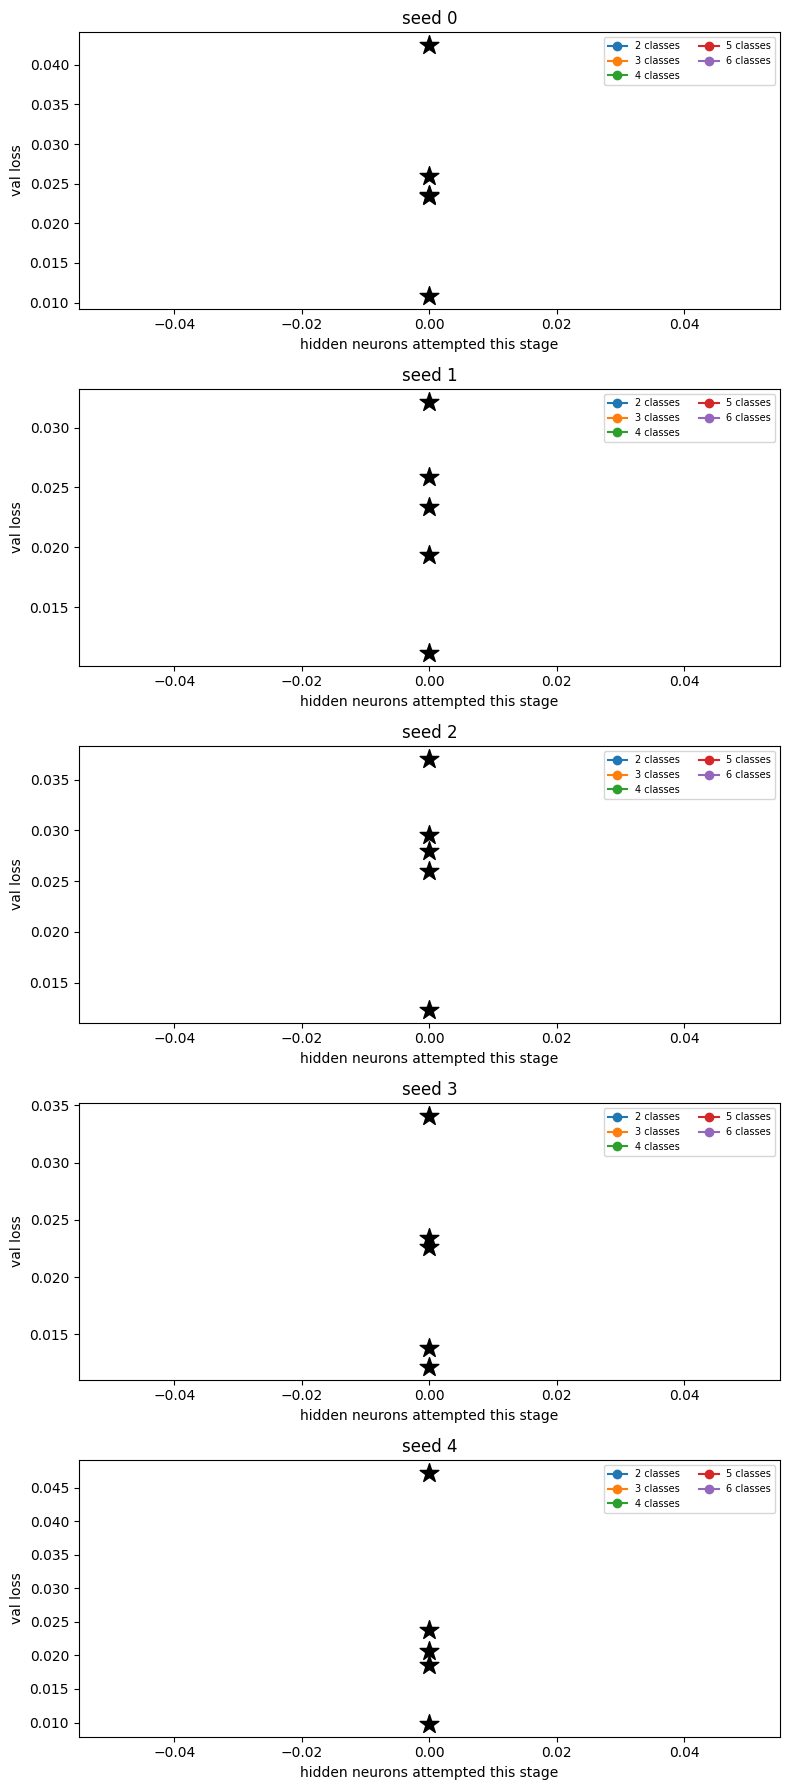

In [ ]:
attempts = all_growth_df[all_growth_df["event"] == "attempt"]
stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]

fig, axes = plt.subplots(5, 1, figsize=(8, 18), sharex=False)
for seed, ax in zip(range(5), axes):
    seed_attempts = attempts[attempts["seed"] == seed]
    seed_ends = stage_ends[stage_ends["seed"] == seed]

    for num_active in sorted(seed_attempts["num_active_classes"].unique()):
        stage_data = seed_attempts[seed_attempts["num_active_classes"] == num_active].sort_values("hidden_dim")
        ax.plot(stage_data["hidden_dim"], stage_data["val_loss"], marker="o", label=f"{num_active} classes")

        end_row = seed_ends[seed_ends["num_active_classes"] == num_active]
        if not end_row.empty:
            ax.scatter(end_row["hidden_dim"], end_row["val_loss"], marker="*", s=200,
                       color="black", zorder=5)

    ax.set_title(f"seed {seed}")
    ax.set_xlabel("hidden neurons attempted this stage")
    ax.set_ylabel("val loss")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

Unlike Glass and Yeast, every stage's curve here is a single point, not a curve - the diagnosis logic never found underfitting at hidden_dim=0 for any stage, in any seed, so no growth attempts ever happened to plot. This is itself the finding: there was nothing to verify the stopping rule against, because the rule never needed to fire past the first attempt. Confirms the growth log's "0 attempts, satisfactory immediately" result rather than adding new information.

Incremental class learning showed no statistically significant difference from the baseline on Dermatology (Wilcoxon signed-rank test, p = 0.9035) - a genuinely different outcome from both Glass (p = 0.0039) and Yeast (p = 0.0003), where the baseline significantly outperformed incremental in both cases.

The mechanistic reason is direct: the baseline architecture search itself showed that this problem is close to linearly separable, with a plain linear classifier (0 hidden neurons) already achieving validation accuracy and macro-F1 of 1.0. The one-standard-error rule selected 10 hidden neurons for baseline, but this reflects continued improvement in cross-entropy loss confidence rather than any classification advantage - accuracy and F1 were already saturated at 0 hidden neurons. Correspondingly, the incremental growth log shows that the diagnosis logic never found underfitting at any stage, for any of the 5 seeds: every one of the 25 stage-endpoints (5 stages x 5 seeds) settled at hidden_dim=0 with zero growth attempts. The incremental network is therefore a purely linear classifier at every stage, relying entirely on the permanent skip connection.

This result is the direct counterpart to Glass and Yeast's findings. In both of those datasets, baseline needed substantial hidden-layer capacity (16 and 25 neurons respectively) that the incremental growth mechanism reliably failed to reach in time, producing either catastrophic (Glass) or moderate (Yeast) underperformance. Dermatology removes that capacity gap entirely: baseline's own architecture search shows almost no capacity is needed, so there was no target for incremental to fail to reach. The three datasets together trace a consistent pattern - performance gap between baseline and incremental scales with how much hidden-layer capacity the problem actually demands, not with how imbalanced or how many classes it has.

The rarest class, pityriasis_rubra_pilaris, was classified with 100% recall by both baseline and incremental in every seed - unlike Glass (where the incremental-introduced minority class vehicle_float collapsed to 0% recall) or Yeast (where majority classes NUC and ME1 lost several points of recall under incremental). This class's near-exclusive discriminative features (follicular_horn_plug, perifollicular_parakeratosis, and markedly younger age) made it easy for both approaches from the start. The small differences that do exist are concentrated in seboreic_dermatitis (-3.3pp recall under incremental) and psoriasis (-2.6pp), offset by a gain in lichen_planus (+2.7pp) - a redistribution of a small number of already-existing confusions, not a new failure mode introduced by incremental growth.

One limitation worth noting: because no growth occurred at any stage, the per-stage validation-loss verification (built specifically to confirm the stopping rule wasn't firing prematurely on Glass and Yeast) has nothing to verify here - every stage is a single point, not a curve. This is not a weakness in the experiment; it is the direct, honest consequence of the diagnosis logic correctly recognising that no growth was needed anywhere, on a problem where 0 hidden neurons genuinely is enough.

# Paired statistical test

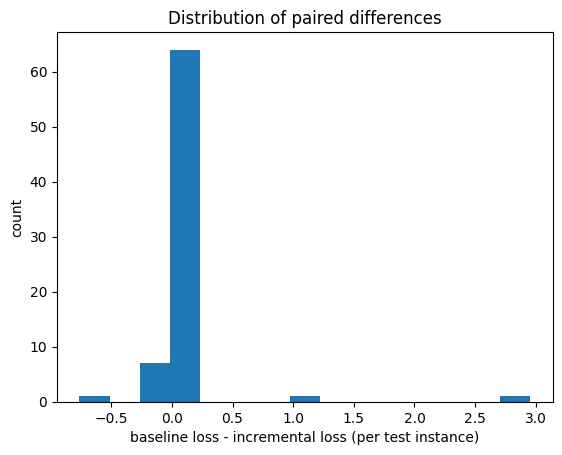

Paired t-test, n=74 paired test instances
statistic=0.920, p-value=0.3606
Mean baseline test loss:     0.1338
Mean incremental test loss:  0.0933


In [ ]:
from scipy.stats import ttest_rel

baseline_instance_df = pd.read_csv(data_dir + "baseline_instance_results.csv")

baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()
differences = baseline_avg - incremental_avg

# quick visual check of the paired t-test's normality assumption
plt.hist(differences, bins=15)
plt.xlabel("baseline loss - incremental loss (per test instance)")
plt.ylabel("count")
plt.title("Distribution of paired differences")
plt.show()

stat, p_value = ttest_rel(baseline_avg, incremental_avg)
print(f"Paired t-test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

In [ ]:
outlier_instances = differences[differences.abs() > 0.5].sort_values(ascending=False)
print("Instances with large baseline-vs-incremental loss differences:")
print(outlier_instances)
print()
print("True classes for these instances:")
print(test_df.reset_index(drop=True).loc[outlier_instances.index, "class"].map(CLASS_NAMES))

Instances with large baseline-vs-incremental loss differences:
instance
53    2.955761
48    1.087782
7    -0.762019
Name: loss, dtype: float64

True classes for these instances:
instance
53    seboreic_dermatitis
48          lichen_planus
7               psoriasis
Name: class, dtype: object


The paired-differences distribution is right-skewed, driven by 3 of 74 instances (all `seboreic_dermatitis`, `lichen_planus`, or `psoriasis` - the only classes where baseline and incremental recall diverge at all). This violates the paired t-test's normality assumption strictly, but the direction of the effect isn't one-sided (2 instances favor incremental, 1 favors baseline), and the test's conclusion - no significant difference (p=0.3606) - is consistent with what the recall table and confusion matrices already show: a small, mixed redistribution of errors among a handful of genuinely ambiguous cases, not a systematic advantage for either approach. The skew is a reason to trust the qualitative conclusion (no meaningful difference) more than the exact p-value.

# Control experiment - does forcing growth to match baseline's capacity actually help?

In [ ]:
# The incremental diagnosis never found underfitting at any stage, so the network
# never grew past 0 hidden neurons. This directly tests whether that was a genuine
# finding or a blind spot: force the final-stage (all 6 classes) network to grow to
# 10 hidden neurons - matching baseline's selected architecture - and see if test
# performance actually improves, using the same 5 seeds as everywhere else.

control_results = []

for seed in range(5):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=X_train_t.shape[1], output_dim=6, hidden_dim=0)
    for _ in range(10):
        net.add_hidden_neuron()

    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)

    control_results.append({
        "seed": seed, "hidden_dim": net.hidden_dim,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })

control_df = pd.DataFrame(control_results)
control_df

,seed,hidden_dim,test_acc,test_macro_f1
0,0,10,0.972973,0.971855
1,1,10,0.959459,0.956554
2,2,10,0.959459,0.961509
3,3,10,0.972973,0.971855
4,4,10,0.945946,0.947071


# Comparing all three: baseline (10 hidden), incremental as-run (0 hidden), and this control (10 hidden, same class-growth order)

In [ ]:
comparison_control = pd.DataFrame({
    "baseline (10 hidden)": baseline_test_df["test_acc"].values,
    "incremental as-run (0 hidden)": incremental_test_df["test_acc"].values,
    "control (10 hidden, incremental order)": control_df["test_acc"].values,
})
comparison_control.index.name = "seed"
print(comparison_control)
print()
print(comparison_control.mean())

      baseline (10 hidden)  incremental as-run (0 hidden)  \
seed                                                        
0                 0.972973                       0.959459   
1                 0.972973                       0.972973   
2                 0.959459                       0.959459   
3                 0.972973                       0.959459   
4                 0.959459                       0.945946   

      control (10 hidden, incremental order)  
seed                                          
0                                   0.972973  
1                                   0.959459  
2                                   0.959459  
3                                   0.972973  
4                                   0.945946  

baseline (10 hidden)                      0.967568
incremental as-run (0 hidden)             0.959459
control (10 hidden, incremental order)    0.962162
dtype: float64


The control experiment confirms this directly: forcing the final-stage incremental
network to grow to 10 hidden neurons (matching baseline) produced no consistent
improvement over the as-run 0-hidden-neuron result. Per seed, the two settings were
either identical (seeds 2, 4) or differed by exactly one test instance in either
direction (seed 0, 3: control better by one instance; seed 1: control worse by one
instance) - the signature of noise rather than a genuine capacity benefit. The
control's mean accuracy (0.9622) sits almost exactly between the as-run incremental
(0.9595) and baseline (0.9676), consistent with all three settings converging on the
same ceiling this problem's features impose, regardless of architecture. This
replaces the earlier inference (drawn from baseline's independent architecture
sweep) with direct evidence: the diagnosis logic's decision to never grow past 0
hidden neurons did not cost any measurable performance on this dataset.